# Random FDLU noising MPS optimization

Created: 08-07-2026

Objectives:
* Apply an MPS hypothesis to tensor network factorization optimization.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [10]:
from time import time

In [11]:
from humanize import naturalsize

# Definitions
## Construct cluster state

In [12]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [13]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [14]:
np_CZ = np.diag([1,1,1,-1])

In [15]:
np_CZ = np_CZ.reshape((2,)*4)

In [16]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [17]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [18]:
psi = get_cluster_state_qu_tensor_network(12)

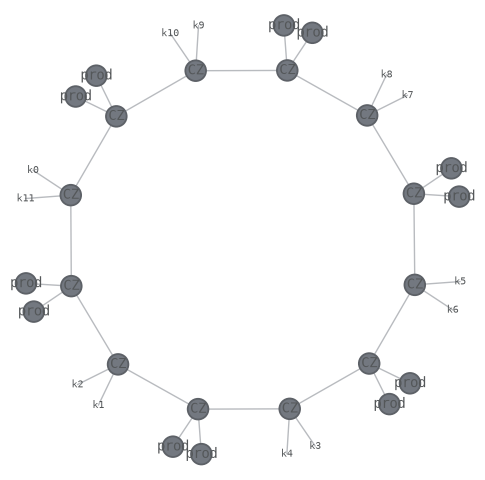

In [19]:
psi.draw()

Looks good. Weird, but good.

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [20]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [21]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [22]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

In [23]:
np_I = np.array([
    [1,0],
    [0,1]
])

In [24]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='I'
)

In [25]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [26]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

## Defect operators

In [27]:
# I don't think we're using this anymore
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [28]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [29]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [30]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [31]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [32]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [33]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [34]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [35]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=2000)

    return A_opt, tnopt.losses, tnopt.loss_best

In [36]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [37]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        cutoff=1e-2,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={
                'bl': (left_defect_op_dim, left_defect_complement_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (right_defect_complement_op_dim, right_defect_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [38]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [39]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['left_defect_sites']
    ]

    central_gates = [
        qu_X.reindex({'k': f'k{i}', 'b':f'b{i}'})
        for i in central_sites
    ]

    right_gates = [
        qu_X.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['right_defect_sites']
    ]

    all_tensors = [
        rho_tilde.reindex(
            {f'b{i}': f'i{i}' for i in domains_dict['left_defect_sites']}
            | {f'b{i}': f'i{i}' for i in domains_dict['right_defect_sites']}
        ),
        *left_gates,
        *central_gates,
        *right_gates
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        qtn.TensorNetwork(all_tensors)
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [40]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl': 'ki2', 'kl': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br': 'ki2', 'kr': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        overlap
    )

    return out

In [41]:
def get_defect_ops_and_indices_from_mps_decomposition_no_symmetry(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    # X is it's own inverse, so I'm ignoring precise index ordering.
    # May not generalize to other operators.
    left_gates = [
        qu_I.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['left_defect_sites']
    ]

    central_gates = [
        qu_I.reindex({'k': f'k{i}', 'b':f'b{i}'})
        for i in central_sites
    ]

    right_gates = [
        qu_I.reindex({'k': f'i{i}', 'b':f'b{i}'})
        for i in domains_dict['right_defect_sites']
    ]

    bra_mps_decomp = mps_decomp.reindex(
        {f'k{i}': f'i{i}' for i in domains_dict['left_defect_sites']}
        | {f'k{i}': f'b{i}' for i in central_sites}
        | {f'k{i}': f'i{i}' for i in domains_dict['right_defect_sites']}
    )

    all_tensors = [
        mps_decomp.mangle_inner_(),
        bra_mps_decomp.mangle_inner_(),
        *left_gates,
        *central_gates,
        *right_gates
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    edm = (
        qtn.TensorNetwork(all_tensors)
        .contract()
        .fuse(fuse_map)
    )

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl': 'ki2', 'kl': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br': 'ki2', 'kr': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        overlap
    )

    return out

In [42]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, domains_dict, 
                        cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={
                                'kl': (left_defect_op_dim, left_defect_complement_op_dim)
                            }
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={
                                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                            }
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [43]:
def get_restricted_psis_from_purification(qt_rho, domains_dict,
                                          cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={
                        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                        'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                    }
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [44]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [45]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [46]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [47]:
def extract_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict)

    pair = get_restricted_psis_from_purification(qt_rho, domains_dict)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [
                sv,
                *get_defect_ops_and_indices_from_restricted_purification_state(
                    psi_0,
                    domains_dict
                )
            ]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

In [48]:
def extract_factorization_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [49]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [50]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [51]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [52]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [53]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# Test runs

## Cluster test 1

In [54]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [55]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [56]:
rho = get_rdm_from_quimb_psi(cluster_psi, domains_dict['symmetry_sites'])

In [57]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [58]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


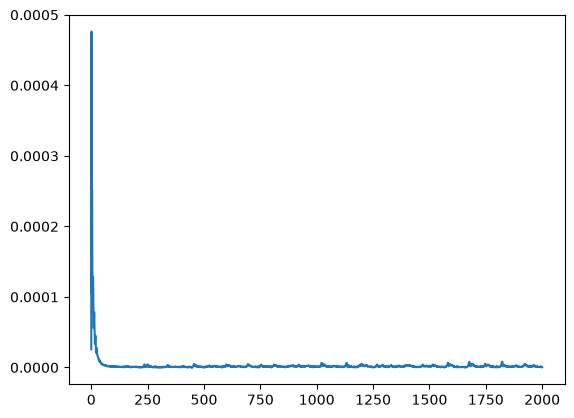

In [59]:
plt.plot(opt_out[1])

In [60]:
opt_out[1][-1]

2.384185791015625e-07

In [61]:
A = opt_out[0]

In [62]:
ind_out = get_defect_ops_and_indices_from_mps_decomposition(rho, A, domains_dict)

In [63]:
ind_out

(array([2.48793693e-01, 1.70685719e-05, 1.26054758e-05, 4.20884105e-06,
        1.03469222e-06, 2.39405766e-08, 8.85838457e-09, 5.78953008e-09,
        1.33601832e-09, 4.94559584e-10, 2.95607337e-10, 1.89103479e-10,
        1.65251315e-10, 4.23785755e-11]),
 Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.99999999999998+0j),
 np.complex128(-0.9999999999999951-2.7755575615628914e-17j),
 [np.float64(0.12247783130260195),
  np.float64(0.9951652725204434),
  np.float64(0.9951653818921123),
  np.float64(0.9951653818921127),
  np.float64(0.9951653818921126),
  np.float64(0.9951653818921127),
  np.float64(0.9951653818921122),
  np.float64(0.9951653818921122),
  np.float64(0.9951653818921122),
  np.float64(0.995165381892112),
  np.float64(0.9951653818921123),
  np.float64(0.9951653818921129),
  np.float64(0.9951653818921121),
  np.float64(0.9951653818921125),
  np.float64(0.995165381892112),
  np.float64(0.99516

## Cluster test 2

In [64]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [11,12,13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [65]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [66]:
rho = get_rdm_from_quimb_psi(cluster_psi, domains_dict['symmetry_sites'])

In [67]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [68]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [69]:
t2 - t1

8.354508638381958

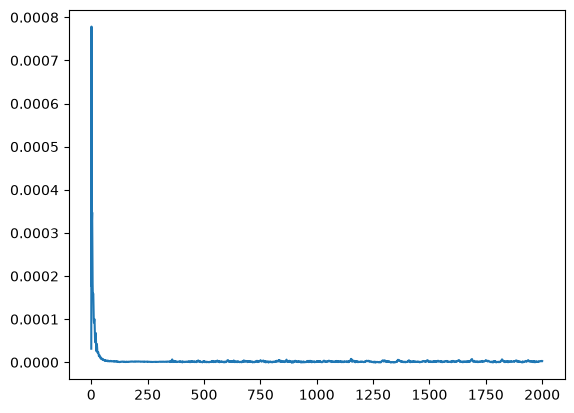

In [70]:
plt.plot(opt_out[1])

In [71]:
opt_out[1][-1]

2.9802322387695312e-06

In [72]:
A = opt_out[0]

In [73]:
ind_out = get_defect_ops_and_indices_from_mps_decomposition(rho, A, domains_dict)

In [74]:
ind_out

(array([2.49894077e-01, 3.14572688e-04, 2.70455688e-05, 2.34633246e-05,
        1.25698252e-05, 9.46281194e-06, 3.88402336e-06, 2.26228081e-06,
        2.23560730e-06, 1.63672915e-06, 1.01335028e-06, 9.09702775e-07,
        1.86058762e-07, 6.06010169e-08, 2.47819722e-08, 2.03626701e-08,
        1.53811795e-08, 5.16893270e-09, 4.61649088e-09, 3.67994179e-09,
        2.91761452e-09, 1.40473219e-09, 8.62129306e-10, 8.39490214e-10,
        4.36950372e-10, 1.96286389e-10, 9.81324142e-11, 8.77763312e-11,
        3.56936241e-11]),
 Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999868031098-7.872723199048304e-09j),
 np.complex128(-0.9999999995329835-4.367429196072692e-10j),
 [np.float64(1.0865576034379132),
  np.float64(0.9997107834145185),
  np.float64(0.9997107931653124),
  np.float64(0.9997107931653206),
  np.float64(0.9997107931653205),
  np.float64(0.9997107931653204),
  np.float64(0.9997107931653

## Run 1

In [75]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [76]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [77]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [78]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [79]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [80]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [81]:
t2 - t1

9.286237239837646

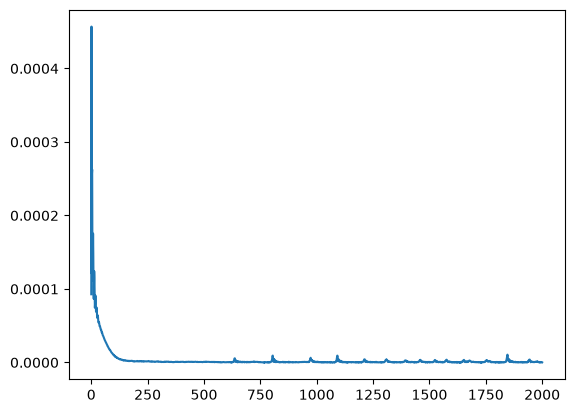

In [82]:
plt.plot(opt_out[1])

In [83]:
opt_out[1][-1]

1.6391277313232422e-07

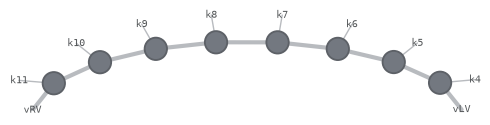

In [84]:
opt_out[0].draw()

In [85]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([7.13525448e-02, 2.71470100e-02, 9.41279876e-04, 5.18536671e-06,
        2.95408182e-06, 1.23663827e-06, 3.89298813e-07, 3.63151282e-07,
        2.79571138e-07, 1.35458011e-07, 5.44619536e-08, 1.96801379e-08,
        1.85826242e-08, 1.22196147e-08, 4.68596476e-09, 1.12992685e-09]),
 Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('kr', 'br'), tags=oset([])),
 np.complex128(1.0000000000000098+1.3877787807814457e-17j),
 np.complex128(1.0000000000000029+1.5073171044654998e-09j),
 [np.float64(0.07896107019683167),
  np.float64(0.2297694018158098),
  np.float64(0.2322040006029233),
  np.float64(0.23225150310593023),
  np.float64(0.23225731628788224),
  np.float64(0.23225806093840307),
  np.float64(0.23225815636814404),
  np.float64(0.23225816860231724),
  np.float64(0.2322581701707818),
  np.float64(0.23225817037187416),
  np.float64(0.2322581703976562),
  np.float64(0.23225817040096172),
  np.float64(0.23225817040138552),
  np.float64(0.2322581704

Tracks.

## Run 2

In [86]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6],
    'right_defect_sites': [13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [87]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [88]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [89]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [90]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [91]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [92]:
t2 - t1

24.755919218063354

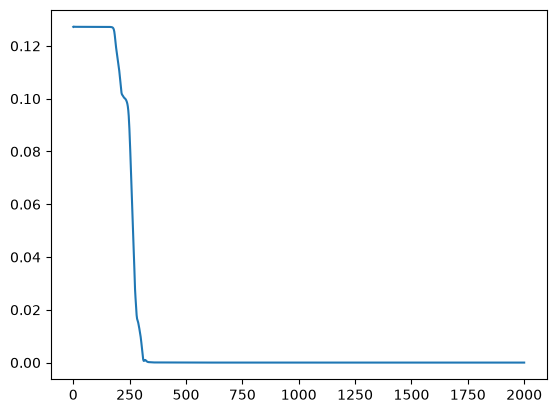

In [93]:
plt.plot(opt_out[1])

In [94]:
opt_out[1][-1]

6.109476089477539e-07

In [95]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([6.34730699e-02, 2.51949512e-05, 2.15458348e-05, 1.72981540e-05,
        3.92651796e-06, 1.46024125e-06, 1.45342968e-06, 9.28936351e-07,
        7.99684123e-07, 5.37159643e-07, 3.91541675e-07, 1.98614005e-07,
        4.92694119e-08, 2.70075353e-08, 1.13991797e-08, 4.81222268e-09]),
 Tensor(shape=(4, 4), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(4, 4), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999999997748-2.7755575615628914e-17j),
 np.complex128(-0.9999999999998904+0j),
 [np.float64(0.1251030986302425),
  np.float64(0.25389218220067455),
  np.float64(0.25389226845385787),
  np.float64(0.2538922684538603),
  np.float64(0.2538922684538603),
  np.float64(0.2538922684538603),
  np.float64(0.25389226845386037),
  np.float64(0.25389226845386015),
  np.float64(0.2538922684538602),
  np.float64(0.25389226845386015),
  np.float64(0.2538922684538602),
  np.float64(0.2538922684538603),
  np.float64(0.2538922684538604),
  np.float64(0.25389226845386037),
  np.float64(

## Run 3

In [96]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7],
    'right_defect_sites': [12,13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [97]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [98]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [99]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [100]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [101]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [102]:
t2 - t1

23.854103803634644

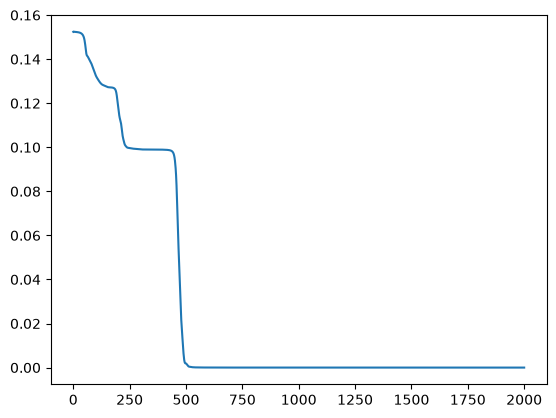

In [103]:
plt.plot(opt_out[1])

In [104]:
opt_out[1][-1]

6.258487701416016e-07

In [105]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([1.02521962e-01, 3.49658778e-02, 7.74185303e-03, 5.09826327e-03,
        2.24237938e-05, 1.34682437e-05, 5.97518148e-06, 5.68514616e-06,
        3.96638420e-06, 3.15759337e-06, 1.56528696e-06, 6.32420149e-07,
        5.75481617e-07, 2.33515929e-07, 1.44449507e-07, 1.21001299e-07,
        7.07374048e-08, 6.03810462e-08, 4.73717693e-08, 3.46730932e-08,
        2.89679464e-08, 2.44017237e-08, 2.12438066e-08, 1.57313105e-08,
        1.20749754e-08, 3.43133840e-09, 2.92943792e-09, 2.24047535e-09,
        1.84804427e-10, 1.49762802e-10, 1.17089682e-10, 7.73375920e-11,
        7.36339756e-11, 6.04759497e-11, 5.25632479e-11, 4.72200332e-11,
        3.60297505e-11, 3.38652884e-11, 2.68512579e-11, 2.33648332e-11,
        1.96919828e-11, 1.90426874e-11, 1.51098121e-11, 1.37130707e-11,
        1.20048769e-11]),
 Tensor(shape=(8, 8), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(8, 8), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999999998764-8.326672684688674e-17j),
 np.comp

## Run 4

In [106]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [11,12,13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [107]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [108]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [109]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [110]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [111]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [112]:
t2 - t1

24.890073776245117

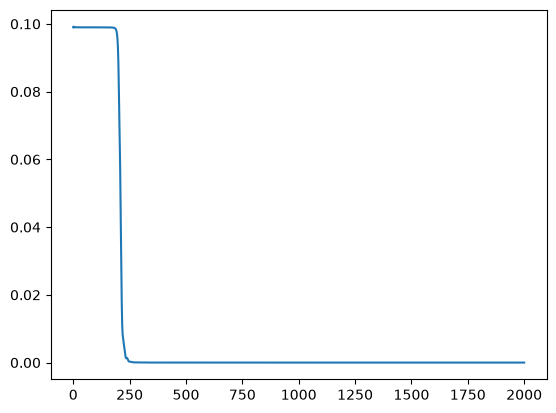

In [113]:
plt.plot(opt_out[1])

In [114]:
opt_out[1][-1]

5.811452865600586e-07

In [115]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([1.76607978e-01, 4.01249151e-02, 9.57034290e-05, 6.58401494e-05,
        2.18488688e-05, 1.52817705e-05, 1.24911578e-05, 1.00553244e-05,
        3.40672431e-06, 3.17866507e-06, 4.41514958e-07, 3.24215496e-07,
        1.63074865e-07, 1.16080026e-07, 7.10755644e-08, 6.89347434e-08,
        3.81584883e-08, 2.37957254e-08, 1.01479988e-08, 7.08596359e-09,
        6.68151400e-09, 3.72956034e-09, 2.59360519e-09, 1.75197876e-09,
        1.15247063e-09, 6.75848447e-10, 5.01058251e-10, 7.74363864e-11,
        6.44321692e-11, 4.23432823e-11, 2.38832336e-11]),
 Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999997312731+8.79477879411894e-11j),
 np.complex128(-0.9999999999999745+1.7286720666032096e-11j),
 [np.float64(0.6827965376629018),
  np.float64(0.9962670784385763),
  np.float64(0.9991989216755949),
  np.float64(0.999350894010586),
  np.float64(0.999358740958388),
  np.float64(0.9993591460292542)

Left and right sides are correlated, hence the invariants are not correct. Tracks.

## Run 5

In [116]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 16)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [12,13,14, 15],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [117]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [118]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [119]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [120]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [121]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [122]:
t2 - t1

19.358874797821045

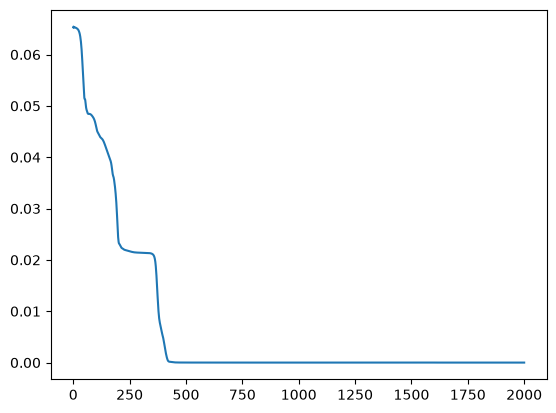

In [123]:
plt.plot(opt_out[1])

In [124]:
opt_out[1][-1]

4.172325134277344e-07

In [125]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([5.48812310e-02, 3.82152656e-02, 4.08972801e-05, 2.75440801e-05,
        2.41077107e-05, 2.18343034e-05, 2.13972022e-05, 1.63479930e-05,
        1.49018537e-05, 1.05898414e-05, 5.49799566e-06, 4.14638744e-06,
        3.45441459e-06, 2.35747444e-06, 1.01051956e-06, 9.49095765e-07,
        5.81694019e-07, 5.73005858e-07, 5.87019828e-08, 4.68010705e-08,
        3.45018370e-08, 3.01661384e-08, 1.08902267e-08, 6.55713598e-09,
        4.34303934e-09, 3.26822075e-09, 2.06701870e-09, 1.98778832e-09,
        1.51210068e-09, 1.23870803e-09, 5.25778273e-10, 5.04436593e-10,
        2.10559825e-10, 1.98489447e-10, 5.34397286e-11, 2.90035506e-11,
        1.79786261e-11, 1.47929387e-11, 7.52130621e-12]),
 Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.9999999999882935+1.377280234304834e-11j),
 np.complex128(-0.9999999999674818+4.053880646101571e-08j),
 [np.float64(0.5073452935282246),
  np.float64(0.4176982

## Run 6

In [126]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(4, 16)),
    'left_symmetry_sites': list(range(4, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': [4,5,6,7],
    'right_defect_sites': [12,13,14, 15],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [127]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [128]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [129]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [130]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [131]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [132]:
t2 - t1

15.975587129592896

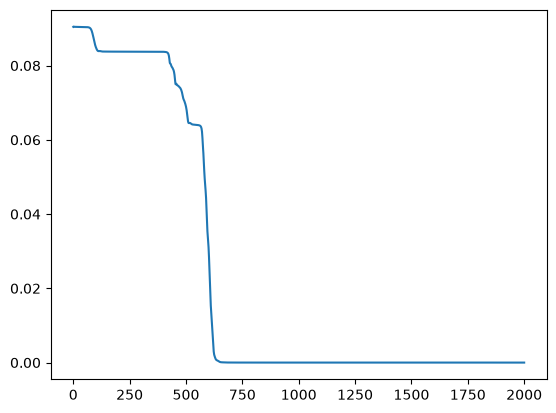

In [133]:
plt.plot(opt_out[1])

In [134]:
opt_out[1][-1]

1.7881393432617188e-07

In [135]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([4.10187162e-02, 3.97326105e-02, 2.95109792e-02, 9.14757857e-03,
        2.22789131e-05, 1.73707097e-05, 1.69934823e-05, 1.57668109e-05,
        1.15598706e-05, 1.05821017e-05, 9.09934040e-06, 9.07978867e-06,
        7.10189562e-06, 6.95854464e-06, 5.73046248e-06, 4.59672116e-06,
        3.19486704e-06, 2.70457190e-06, 2.51530244e-06, 2.02993421e-06,
        2.02578576e-06, 1.54113163e-06, 7.71211656e-07, 1.23639520e-07,
        3.31831931e-09, 2.53818996e-10, 1.49176012e-10, 6.15056053e-11,
        5.80575702e-11, 3.21292954e-11, 2.05050261e-11, 1.51309195e-11,
        9.43788508e-12, 8.87855986e-12, 5.09359941e-12, 4.21777511e-12]),
 Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.030176475471293582+4.170021877656412e-05j),
 np.complex128(-0.07086567899671059+7.581776342496793e-06j),
 [np.float64(0.13256565792543382),
  np.float64(0.39446106467105535),
  np.float64(0.40884573162325505),
  np

## Run 7

In [136]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(2, 14)),
    'left_symmetry_sites': list(range(2, 8)),
    'right_symmetry_sites': list(range(8, 14)),
    'left_defect_sites': [2,3,4,5],
    'right_defect_sites': [10, 11, 12, 13],
    'fdlu_depth': 2,
    'fdlu_offset': 0,
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [137]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [138]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [139]:
rho = get_rdm_from_quimb_psi(rand_psi, domains_dict['symmetry_sites'])

In [140]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [141]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

In [142]:
t2 - t1

12.509183406829834

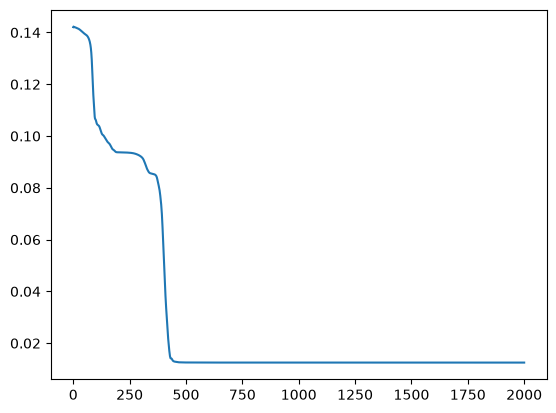

In [143]:
plt.plot(opt_out[1])

In [144]:
opt_out[1][-1]

0.012508407235145569

In [145]:
get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

(array([9.68317472e-02, 1.07734068e-02, 4.26384779e-05, 2.95399921e-05,
        2.31259205e-05, 1.83942767e-05, 1.42381905e-05, 1.36174163e-05,
        9.99124248e-06, 7.60405153e-06, 6.01681018e-06, 4.85632865e-06,
        4.41972806e-06, 3.62686820e-06, 3.46726203e-06, 2.65794517e-06,
        2.47715469e-06, 2.19989023e-06, 1.47775626e-06, 1.29984732e-06,
        1.16164122e-06, 1.02992173e-06, 6.15886559e-07, 5.55477584e-07,
        3.03287259e-07, 2.29113363e-07, 1.22688499e-07, 5.83222736e-08,
        2.41631607e-09, 1.18448799e-09, 8.55022572e-10, 6.90351736e-10,
        5.66563216e-10, 4.60490610e-10, 3.65222302e-10, 3.24479161e-10,
        2.41551630e-10, 2.34805763e-10, 1.42709287e-10, 1.27564410e-10,
        9.92180479e-11, 5.60722932e-11, 5.52457523e-11, 2.51131544e-11,
        1.93197624e-11, 1.63851689e-11, 9.87174892e-12]),
 Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('kr', 'br'), tags=oset([])),
 np.complex128(-0.99999999999993

# Conclusions
Looks good!